<a href="https://colab.research.google.com/github/leinguyenpei-eng/-LazyLean-The-Science-Backed-Weight-Loss-Guide-for-Lazy-Smart-People/blob/main/noshow_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3

# Load CSV
df = pd.read_csv('KaggleV2-May-2016.csv')

# Xem data
print(df.shape)
df.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
# Explore column names
print("Columns:", df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check no-show distribution
print("\nNo-show distribution:")
print(df['No-show'].value_counts())
print(df['No-show'].value_counts(normalize=True).round(2))

Columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

Missing values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

No-show distribution:
No-show
No     88208
Yes    22319
Name: count, dtype: int64
No-show
No     0.8
Yes    0.2
Name: proportion, dtype: float64


In [ ]:
# Create SQLite database from dataframe
conn = sqlite3.connect('noshow.db')

# Load data into SQL table
df.to_sql('appointments', conn, if_exists='replace', index=False)

print("Database created successfully!")
print("Total records:", pd.read_sql("SELECT COUNT(*) as total FROM appointments", conn).iloc[0,0])

Database created successfully!
Total records: 110527


In [ ]:
# Query 1: No-show rate by gender
query1 = """
SELECT Gender,
       COUNT(*) as total,
       SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) as no_show_count,
       ROUND(SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as no_show_rate
FROM appointments
GROUP BY Gender
ORDER BY no_show_rate DESC
"""
print("=== No-show Rate by Gender ===")
print(pd.read_sql(query1, conn))

# Query 2: No-show rate by SMS received
query2 = """
SELECT SMS_received,
       COUNT(*) as total,
       ROUND(SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as no_show_rate
FROM appointments
GROUP BY SMS_received
ORDER BY SMS_received
"""
print("\n=== No-show Rate by SMS Received ===")
print(pd.read_sql(query2, conn))

=== No-show Rate by Gender ===
  Gender  total  no_show_count  no_show_rate
0      F  71840          14594         20.31
1      M  38687           7725         19.97

=== No-show Rate by SMS Received ===
   SMS_received  total  no_show_rate
0             0  75045         16.70
1             1  35482         27.57


In [ ]:
# Query 3: No-show rate by age group
query3 = """
SELECT
    CASE
        WHEN Age < 18 THEN 'Under 18'
        WHEN Age BETWEEN 18 AND 35 THEN '18-35'
        WHEN Age BETWEEN 36 AND 60 THEN '36-60'
        ELSE 'Over 60'
    END as age_group,
    COUNT(*) as total,
    ROUND(SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as no_show_rate
FROM appointments
GROUP BY age_group
ORDER BY no_show_rate DESC
"""
print("=== No-show Rate by Age Group ===")
print(pd.read_sql(query3, conn))

=== No-show Rate by Age Group ===
  age_group  total  no_show_rate
0     18-35  25624         23.82
1  Under 18  27380         21.90
2     36-60  37761         19.10
3   Over 60  19762         15.21


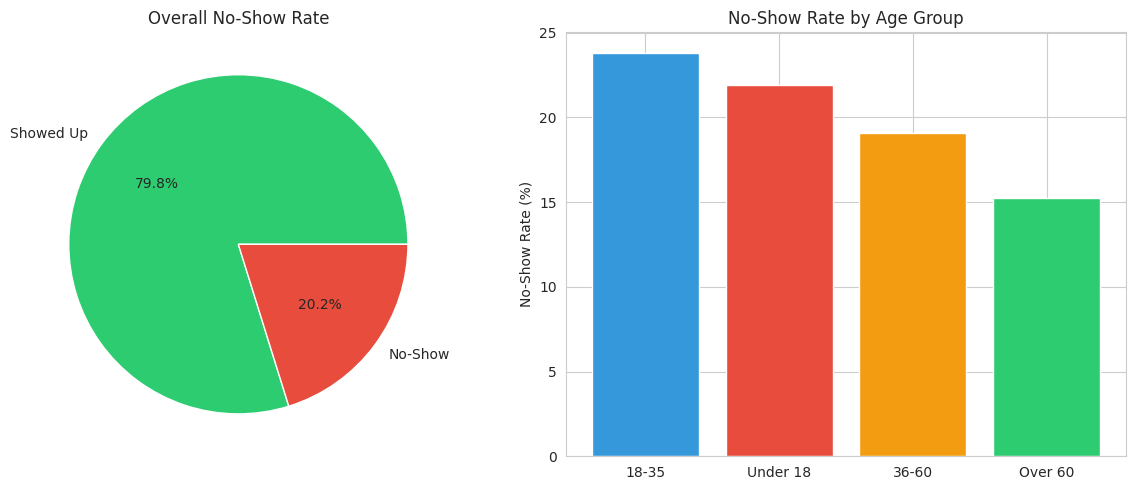

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Plot 1: No-show distribution
fig, axes = plt.subplots(1, 2)

# Pie chart
axes[0].pie([88208, 22319], labels=['Showed Up', 'No-Show'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Overall No-Show Rate')

# Bar chart by age group
age_data = pd.read_sql(query3, conn)
axes[1].bar(age_data['age_group'], age_data['no_show_rate'],
            color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('No-Show Rate by Age Group')
axes[1].set_ylabel('No-Show Rate (%)')

plt.tight_layout()
plt.show()

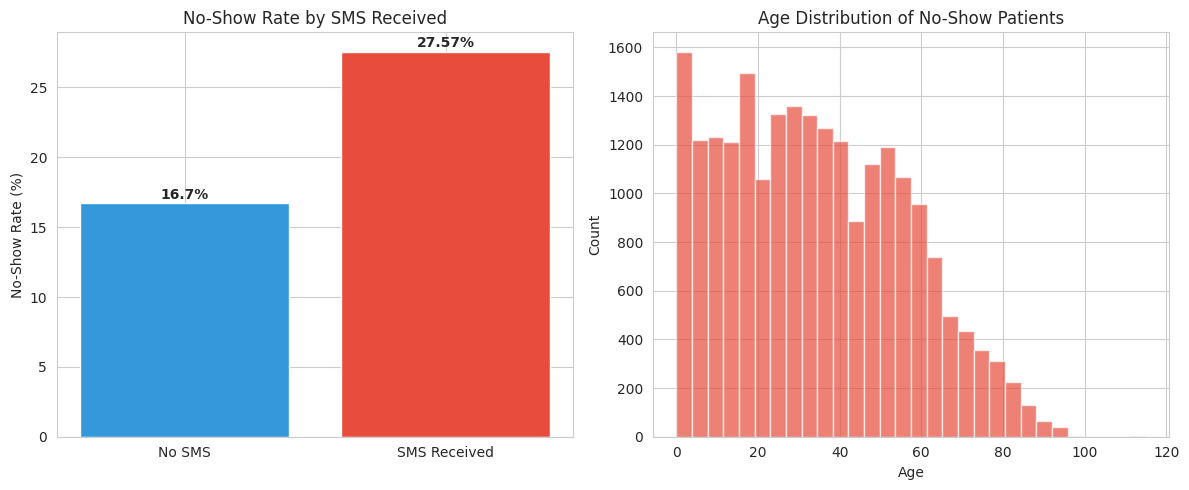

In [ ]:
fig, axes = plt.subplots(1, 2)

# Chart 1: No-show by SMS received
sms_data = pd.read_sql(query2, conn)
axes[0].bar(['No SMS', 'SMS Received'], sms_data['no_show_rate'],
            color=['#3498db', '#e74c3c'])
axes[0].set_title('No-Show Rate by SMS Received')
axes[0].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(sms_data['no_show_rate']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 2: Age distribution of no-shows
no_show_df = df[df['No-show'] == 'Yes']
axes[1].hist(no_show_df['Age'], bins=30, color='#e74c3c', alpha=0.7)
axes[1].set_title('Age Distribution of No-Show Patients')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Feature engineering
df_ml = df.copy()

# Encode categorical columns
df_ml['Gender'] = LabelEncoder().fit_transform(df_ml['Gender'])
df_ml['No-show'] = LabelEncoder().fit_transform(df_ml['No-show'])

# Calculate days between scheduled and appointment
df_ml['ScheduledDay'] = pd.to_datetime(df_ml['ScheduledDay'])
df_ml['AppointmentDay'] = pd.to_datetime(df_ml['AppointmentDay'])
df_ml['days_wait'] = (df_ml['AppointmentDay'] - df_ml['ScheduledDay']).dt.days

# Select features
features = ['Gender', 'Age', 'Scholarship', 'Hipertension',
            'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'days_wait']

X = df_ml[features]
y = df_ml['No-show']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (88421, 9)
Test set: (22106, 9)


In [ ]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# Compare results
print("=== Model Comparison ===")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=['Showed Up', 'No-Show']))

=== Model Comparison ===
Logistic Regression AUC: 0.6540
Random Forest AUC:       0.6678

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

   Showed Up       0.82      0.91      0.86     17669
     No-Show       0.35      0.20      0.26      4437

    accuracy                           0.77     22106
   macro avg       0.59      0.55      0.56     22106
weighted avg       0.73      0.77      0.74     22106



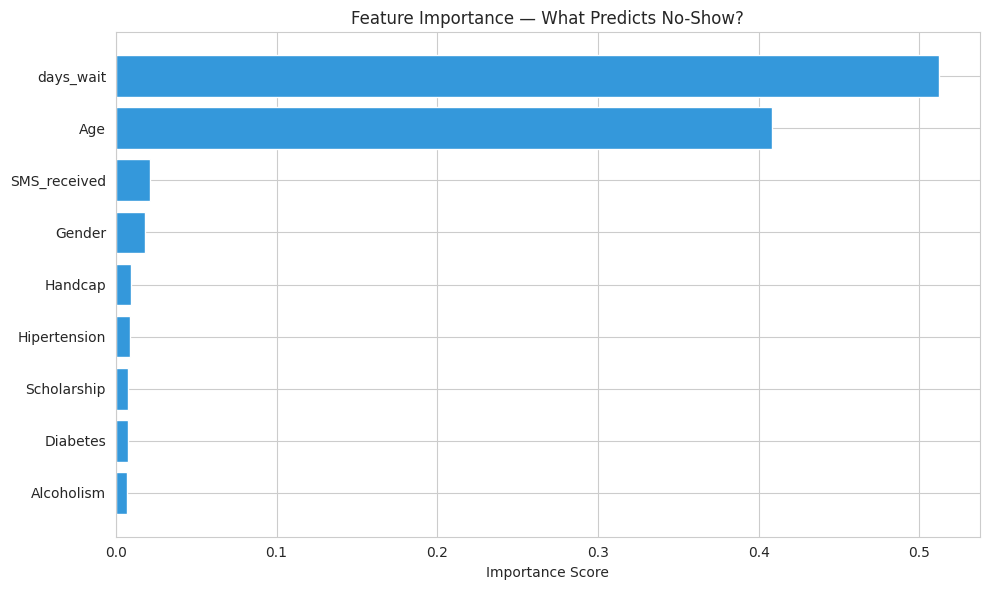


Top 3 predictors:
     feature  importance
SMS_received    0.021054
         Age    0.408385
   days_wait    0.512146


In [ ]:
# Plot feature importance
feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance['feature'], feat_importance['importance'],
         color='#3498db')
plt.title('Feature Importance — What Predicts No-Show?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 predictors:")
print(feat_importance.tail(3)[['feature','importance']].to_string(index=False))

In [ ]:
# Save predictions for Power BI
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = rf_pred
X_test_copy['no_show_probability'] = rf.predict_proba(X_test)[:,1]

X_test_copy.to_csv('noshow_predictions.csv', index=False)
print("Saved! Shape:", X_test_copy.shape)
print(X_test_copy.head())

Saved! Shape: (22106, 12)
        Gender  Age  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
84674        0   20            0             0         0           0        0   
3635         0   37            0             0         0           0        0   
16605        0   38            0             0         0           0        0   
103942       0   24            0             0         0           0        0   
274          0   41            0             0         0           0        0   

        SMS_received  days_wait  actual  predicted  no_show_probability  
84674              0         -1       0          0             0.040452  
3635               1         34       0          0             0.094306  
16605              0          7       1          1             0.639571  
103942             1         30       1          1             0.833333  
274                0         -1       0          0             0.032896  
